In [1]:
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.compiler import transpile
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2  # Qiskit Aer is broken on Python 3.14, this is best alternative

from shift_operators import ShiftDown, ShiftUp

In [2]:
n = 3
main = QuantumRegister(n, "q")
ancillae = QuantumRegister(2, "anc")
anc_meas = ClassicalRegister(2, "anc_meas")

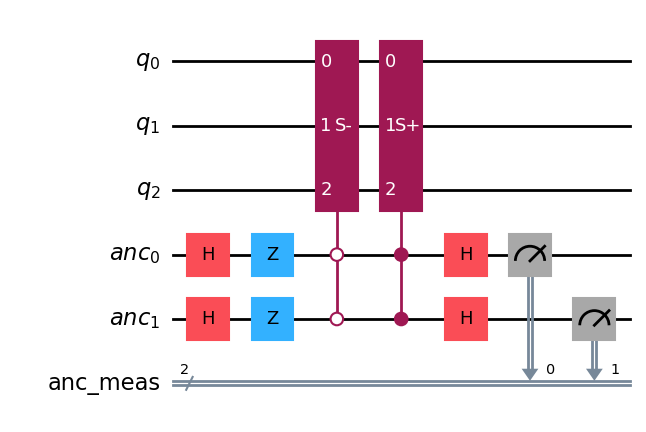

In [3]:
csdown = ShiftDown(n).control(2, ctrl_state=0)
csup = ShiftUp(n).control(2, ctrl_state=3)
qc = QuantumCircuit(main, ancillae, anc_meas)

# Block encoding
qc.h(ancillae)
qc.z(ancillae)
qc.append(csdown, ancillae[:] + main[:])
qc.append(csup, ancillae[:] + main[:])
qc.h(ancillae)
qc.measure(ancillae, anc_meas)

qc.draw(output="mpl")

## Running the quantum circuit

It would have been preferable to do an exact statevector simulation, but Qiskit Aer is currently broken on Python 3.14.
I'll have to either downgrade python or wait for a fix.

This is kind of more of a simple demo so not a big deal, I'm guessing we're gonna run later stuff on real hardware anyway.

We see in the simulations that the expected distribution is obtained, where $|j \rangle$ gets mapped to a state proportional to $|j-1 \rangle - 2 |j \rangle + |j+1 \rangle$.

In [9]:
def build_qc(n, init_state=0):
    assert init_state < 2 ** n
    
    # State preparation for |j>
    bitstring = format(init_state, f"0{n}b")
    bitlist = [int(bit) for bit in bitstring][::-1]

    # Creating register for circuit
    main = QuantumRegister(n, "q")
    ancillae = QuantumRegister(2, "anc")
    main_meas = ClassicalRegister(n, "q_meas")
    anc_meas = ClassicalRegister(2, "anc_meas")
    
    # Creating circuit and shift gates
    csdown = ShiftDown(n).control(2, ctrl_state=0)
    csup = ShiftUp(n).control(2, ctrl_state=3)
    qc = QuantumCircuit(main, ancillae, main_meas, anc_meas)

    # Apply X gates to prepare initial |j> state
    for i, v in enumerate(bitlist):
        if v == 1:
            qc.x(main[i])

    # Building block encoding circuit
    qc.h(ancillae)
    qc.z(ancillae)
    qc.append(csdown, ancillae[:] + main[:])
    qc.append(csup, ancillae[:] + main[:])
    qc.h(ancillae)
    qc.measure(ancillae, anc_meas)
    qc.measure(main, main_meas)

    return qc

In [5]:
# Run circuit and get counts
backend = FakeGuadalupeV2()

n = 3
counts = []

for i in range(2 ** n):
    qc = build_qc(n, i)
    qc_transpiled = transpile([qc], backend)
    job = backend.run(qc_transpiled, shots=10000)
    counts.append(job.result().get_counts())

In [6]:
# Post process results. Drop counts where ancilla meas is not 0.
# Using the fact we used 10 000 shots, we have a success rate of roughly 35%

counts_post_processed = []

for i, cnt in enumerate(counts):
    curr_counts = {}

    for key in cnt:
        # Key takes the form "{anc meas} {main meas}", for example, "01 101"
        # We are only interested in the case where anc_meas = 00, so populate counts_post_processed with dictionaries containing only those
        
        if key[:2] == "00":
            curr_counts[key[3:]] = cnt[key]

    counts_post_processed.append(curr_counts)

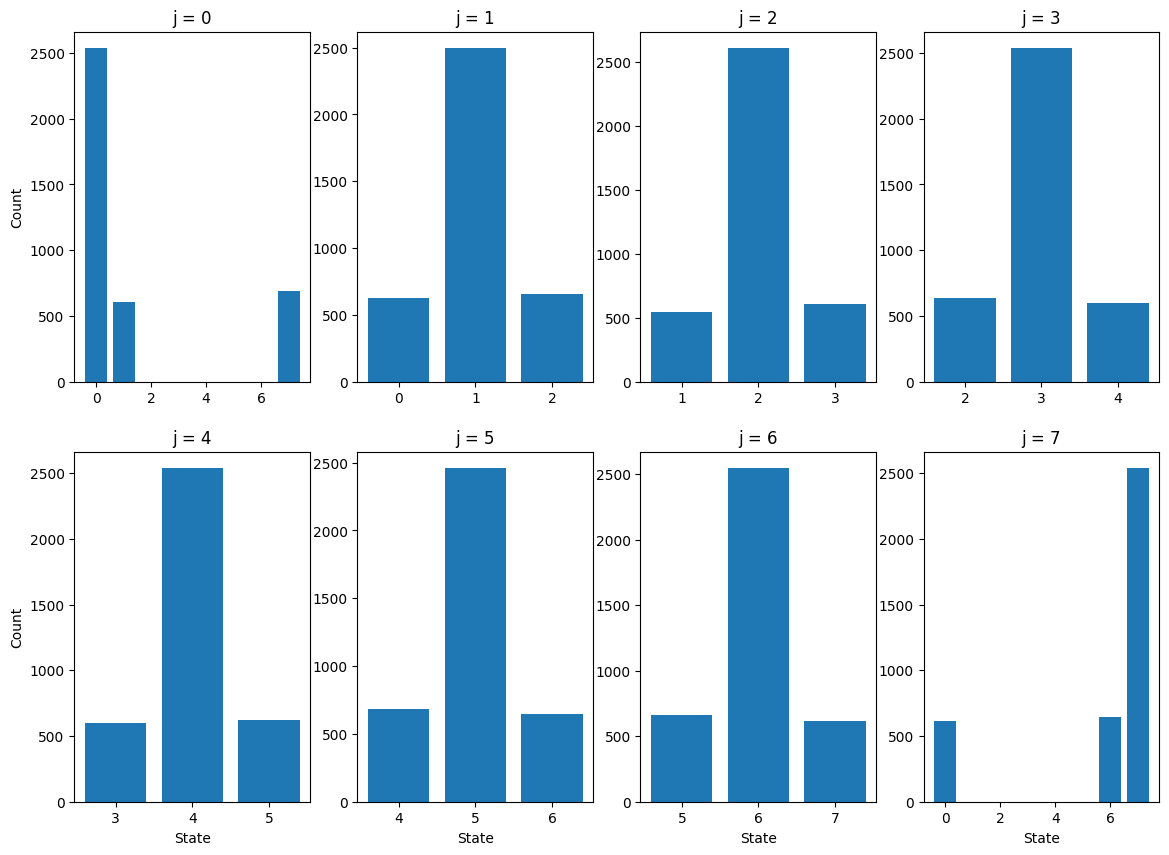

In [8]:
# Create a plot of counts for j from 0 to 7
fig, axs = plt.subplots(2, 4, figsize=(14, 10))

for i, cnt in enumerate(counts_post_processed):
    row, col = i // 4, i % 4
    curr_counts = counts_post_processed[i]
    
    labels = [int(bitstring, 2) for bitstring in curr_counts.keys()]
    values = curr_counts.values()

    axs[row, col].set_title(f"j = {i}")
    axs[row, col].bar(labels, values)

for i in range(2):
    axs[i, 0].set_ylabel("Count")

for i in range(4):
    axs[1, i].set_xlabel("State")

plt.show()